# Simple model with Flow Matching

Attempting to do the same thing as in `simple_model.ipynb`, but using Flow Matching instead of MCMC sampling. 

In [ ]:
import sys
sys.path.append('..')

from src.simulator import BurstSimulator, Model
from src.flow_matching.distributions import Sampleable, Prior, Posterior
from src.flow_matching.probability_path import LinearConditionalProbabilityPath, GuidedLinearProbabilityPath
from src.flow_matching.training import ConditionalFlowMatchingTrainer, GuidedConditionalFlowMatchingTrainer
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPVectorField, MLPGuidedVectorField, LightCurveThinner
from src.helpers import record_every, hist2d_samples

import numpy as np
from matplotlib import pyplot as plt
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

# Example CFM for SBI
Transforming a uniform prior distribution (with enforced order, i.e. $t_1$ < $t_2$>) to a delta function posterior centered on [`true_t0_1`, `true_t0_2`], without the guidance of simulated data. 

In [ ]:
# Samplelable posterior 
class DeltaPosterior(Sampleable):

    """
    This is now for a given datapoint, so just samples true_t0_1, true_t0_2.
    Essentially a delta function.
    """
    def sample(self, num_samples: int) -> torch.Tensor:
        """
        Args:
            num_samples: number of samples to generate
        Returns:
            torch.Tensor: shape (num_samples, 2)
        """
        t0_1 = 0.1 * torch.ones((num_samples, 1))
        t0_2 = 0.6 * torch.ones((num_samples, 1))
        return torch.cat((t0_1, t0_2), dim=1)

# construct conditional probability path
path = LinearConditionalProbabilityPath(
    p_simple = Prior(),
    p_data = DeltaPosterior()
).to(device)

# construct learnable vector field
linear_flow_model = MLPVectorField(dim=2, hiddens=[64,64,64,64])

# construct trainer
trainer = ConditionalFlowMatchingTrainer(path, linear_flow_model)
losses = trainer.train(num_epochs=1000, device=device, lr=1e-3, batch_size=2000, save_checkpoint=False)

Training model with size: 0.049 MiB


Epoch 999, loss: 0.006: : 1000it [00:26, 37.45it/s]


100%|██████████| 99/99 [00:04<00:00, 21.37it/s]


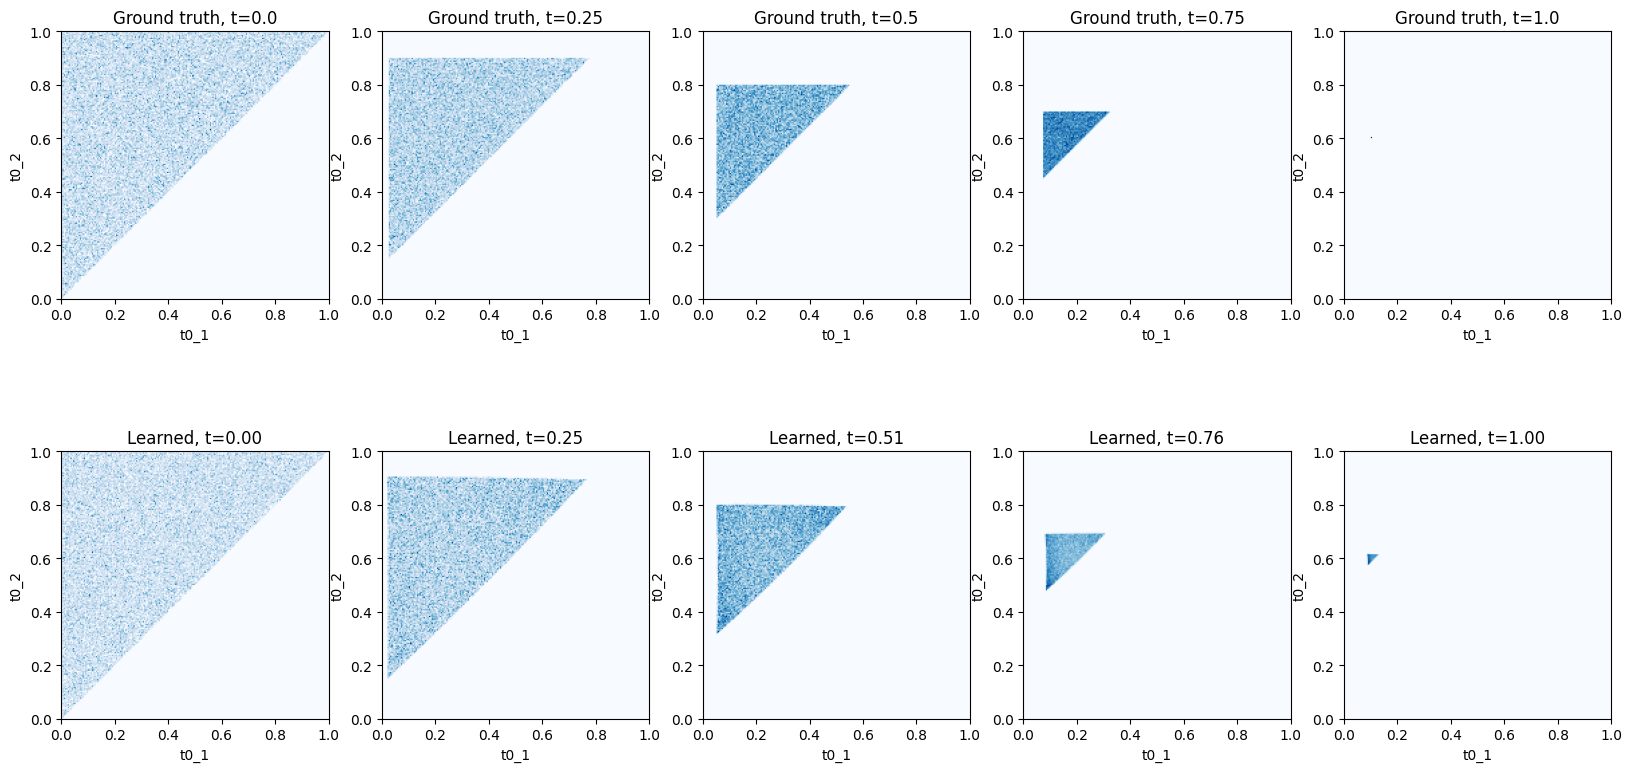

In [ ]:
num_samples = 50000  # number of samples per snapshot
num_marginals = 5    # number of snapshots to plot

plt.figure(figsize=(20,10))

# ----------------------------- #
# Graph Ground-Truth Marginals  #
# ----------------------------- #
ts = torch.linspace(0.0, 1.0, num_marginals).to(device)
for idx, t in enumerate(ts):
    tt = t.view(1,1).expand(num_samples,1)
    xts = path.sample_marginal_path(tt)

    plt.subplot(2, num_marginals, idx + 1)
    hist2d_samples(xts, range=[[0,1], [0,1]], percentile=100, cmap='Blues')

    plt.title(f"Ground truth, t={t.item()}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

# -----------------------------------------#
# Graph Marginals of Learned Vector Field  #
# -----------------------------------------#

# initialize ODE solver
simulator = EulerODESolver(linear_flow_model)
ts = torch.linspace(0,1,100).to(device)

# solve / simulate ode starting from x0
x0 = path.p_simple.sample(num_samples)
xts = simulator.solve_with_trajectory(x0, ts.view(1,-1,1).expand(num_samples,-1,1))

# only save num_marginal snapshots
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

subplot_idx = idx + 1 # for plotting 

for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    t = ts.cpu()[record_every_idxs[idx]]

    plt.subplot(2, num_marginals, subplot_idx + idx + 1)
    
    hist2d_samples(xx, range=[[0,1], [0,1]], percentile=100, cmap='Blues')
    plt.title(f"Learned, t={t:.2f}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

plt.show()

# Adding guiding with simulated data for fixed parameters
Now want to do guided flow matching, meaning the transformation is guided by a sample from the simulated dataset. This means during training we train using sample pairs (p, d) where p are the parameters and d is the corresponding simulated data generated with the simulator with input p. The input of the network in the end will be prior sample p_r, the simulated data and point in time $t\sim U(0, 1)$. The output of the solved ODE with the learned vector field is a sample from the posterior. We have to change several functions to accomodate training pairs (p, d). 

In [2]:
# from src.flow_matching.distributions import Prior, Posterior

path = GuidedLinearProbabilityPath(
    p_simple=Prior(),
    p_data=Posterior()
)

latent_dim = 100
time_seq_encoder = LightCurveThinner(latent_dim=latent_dim)

vector_field = MLPGuidedVectorField(dim=2, hiddens=[64, 64, 32, 16], y_dim=latent_dim, time_seq_encoder=time_seq_encoder)

trainer = GuidedConditionalFlowMatchingTrainer(path, vector_field)
losses = trainer.train(2000, device, 5e-4, save_checkpoint=True, batch_size=256)

Training model with size: 0.051 MiB


Epoch 1999, loss: 0.060: 100%|██████████| 2000/2000 [03:05<00:00, 10.79it/s]


100%|██████████| 99/99 [00:01<00:00, 89.52it/s]


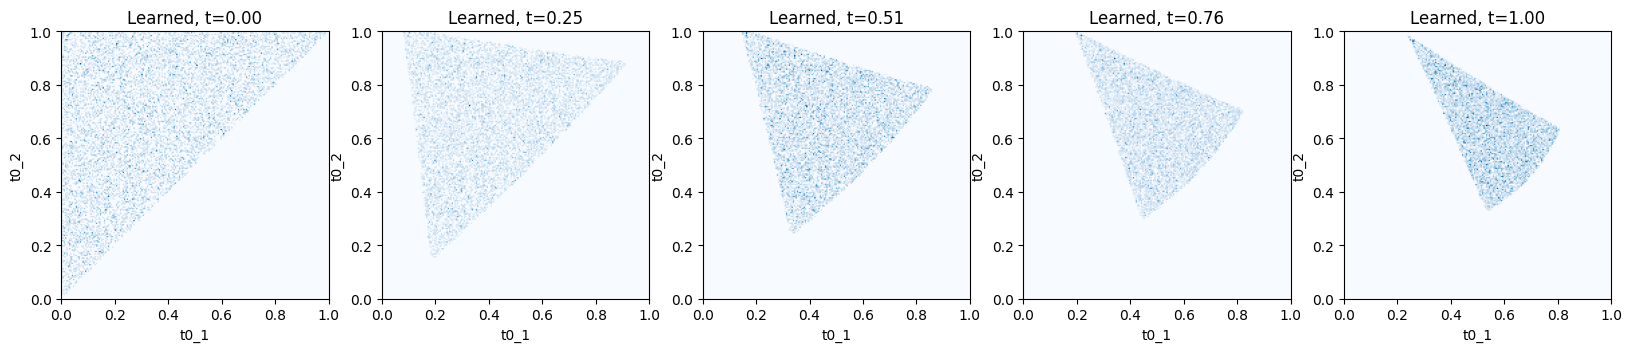

/tmp/ipykernel_10077/2146115043.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


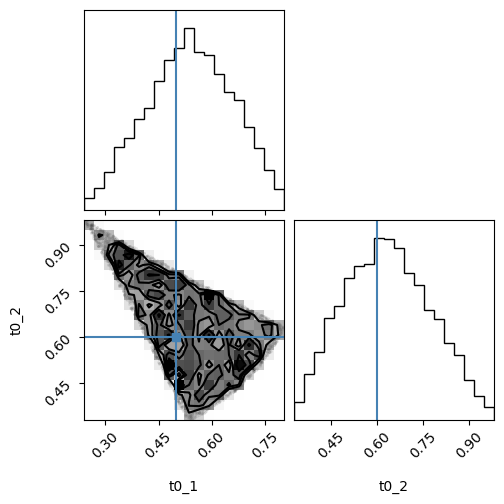

In [7]:
# --------------------------------------------- #
#   Plot Marginal Path of Learned Vector Field  #
# --------------------------------------------- #

# generate one instance of simulated data to guide prior samples with

# fixed model parameters (NOTE: Should be same as used during training in PairedPosterior)
N = 2
time = np.linspace(0, 1.0, 1000)
amp  = 25.0
rise = 0.03
skew = 5
ybkg = 5.0
true_t0 = [0.5, 0.6] # NOTE: this has to obey the prior! (i.e. t0_1 < t0_2 < ... < t0_n)

# generate simulated data for one burst
burstparams = {
    't0'   : true_t0, 
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

model = Model(
    time=time,
    ncomp=N, 
    burstparams=burstparams, 
    ybkg=ybkg
    )

simulator = BurstSimulator(model)
x_counts = torch.Tensor(simulator.simulate_burst())

num_samples = 10000  # number of prior samples to transform 
num_marginals = 5   # number of snapshots

# use same data for all prior samples
simulation_time_resolution = 1000
simulations = torch.zeros((num_samples, simulation_time_resolution)).to(device)

for row_nr in range(len(simulations)):
    simulations[row_nr, :] = x_counts

# Initialize ODE solver
solver = EulerODESolver(vector_field)
ts = torch.linspace(0, 1, 100).to(device)

# simulate ODE starting from x0   # TODO: should simulation be from the one used in training? 
x0 = path.p_simple.sample(num_samples)
xts = solver.solve_with_trajectory(x0, ts.view(1, -1, 1).expand(num_samples,-1,1), y=simulations)

# only save num_marginals snapshots 
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

# plot snapshots of marginal path
plt.figure(figsize=(20, 5))

for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    t = ts.cpu()[record_every_idxs[idx]]

    plt.subplot(1, num_marginals, idx + 1)
    
    # plt.hist2d(x=xx[:, 0], y=xx[:, 1], bins=50, cmap='Blues')
    hist2d_samples(xx, range=[[0,1], [0,1]], percentile=100, cmap='Blues')
    plt.title(f"Learned, t={t:.2f}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

plt.show()

# TODO: Plot t=1 like a corner plot ?
from corner import corner

# print(xx, type(xx), xx.shape)
fig = corner(xx.numpy(), labels=["t0_1", "t0_2"], truths=np.array(true_t0))
fig.show()